# Exemplo 6 - Problema da Mochila Binária


# 1. Configuração do Ambiente

Nesta etapa, configuramos o ambiente do Google Colab para utilizar a linguagem de otimização **CMPL**.

Essa célula deve ser executada apenas:
- Ao abrir o notebook pela primeira vez
- Ou quando o ambiente for reiniciado/desconectado

O que será feito:
- Download do COLIOP/CMPL (disponível em [coliop.org](https://www.coliop.org/download.html))
- Extração dos arquivos
- Configuração de variáveis de ambiente
- Inclusão das bibliotecas no Python

In [1]:
### Esta célula dever ser executada apenas quando o notebook for aberto
### ou quando o ambiente for desconectado e for necessário reconectá-lo
### por inatividade!

# Importação de bibliotecas do sistema
import os, sys

# Baixa o pacote do CMPL a partir do site oficial
os.system("wget https://www.coliop.org/_download/Cmpl-2-1-0-linux64.tar.gz")

# Extrai o arquivo baixado
os.system("tar -xzf Cmpl-2-1-0-linux64.tar.gz")

# Define o diretório principal do CMPL
os.environ["CMPLHOME"] = "/content/Cmpl-2-1-0-linux64"

# Adiciona o executável do CMPL ao PATH do sistema
os.environ["PATH"] += ":/content/Cmpl-2-1-0-linux64/bin"

# Configura bibliotecas compartilhadas necessárias
os.environ["LD_LIBRARY_PATH"] = "/content/Cmpl-2-1-0-linux64/bin/lib:" + os.environ.get("LD_LIBRARY_PATH", "")

# Adiciona os módulos Python do CMPL ao caminho de importação
sys.path.append("/content/Cmpl-2-1-0-linux64/pyCmpl")
sys.path.append("/content/Cmpl-2-1-0-linux64/pyCmpl/lib3")
sys.path.append("/content/Cmpl-2-1-0-linux64/pyCmpl/scripts/Unix")

# 2. Definição do Modelo de Otimização

Aqui definimos um problema de **programação binária** usando a linguagem do CMPL.

## 2.1 Objetivo:
Maximizar o retorno total da carteira.

## 2.2 Elementos do modelo:
- **I**: Conjunto de projetos disponíveis.
- **Capital**: Capital necessário para investir num dado projeto.
- **Retorno**: Retorno esperado do investimento num dado projeto.
- **K**: Orçamento disponível.

## 2.3 Variável de decisão:
- `x[i]`: 1, se o projeto `i` for selecionado; 0, caso contrário.

In [3]:
# Definição do modelo combinado (dados e generalização) em linguagem CMPL (como string)
codigo_cmpl = """

# Modelo de Seleção de Portfólio de Investimentos (Knapsack Problem)

par:
    # Conjunto de Projetos (I = {1, 2, ..., 7})
    I := set(1..7);

    # Limite de orçamento disponível
    K := 4;

    CAPITAL[I] := (0.8, 0.95, 0.68, 1.5, 1.7, 1.1, 0.78);
    RETORNO[I] := (1.2, 1.5, 0.9, 2, 2.5, 1.8, 1.4);

var:
    x[I] : binary;

obj:
    # Função Objetivo: Maximizar o retorno total esperado da carteira
    retorno: sum{i in I: RETORNO[i] * x[i]} -> max;

con:
    # Restrição: O custo total dos projetos selecionados não pode exceder o orçamento B
    orcamento{:sum{i in I: CAPITAL[i] * x[i]} <= K;}

"""

# Salva o modelo em um arquivo .cmpl
with open("/content/Exemplo-6_problema_da_mochila_binaria.cmpl", "w") as f:
    f.write(codigo_cmpl)

# 3. Resolução do Modelo

Nesta etapa utilizamos a **API Python pyCmpl** para fazer a integração entre modelo e resolvedor:
1. Carregamos o modelo criado
2. Executamos o solver
3. Exibimos o relatório da solução
4. Tratamento de erro para capturar possíveis problemas.

Também é possível fazer a entrada de dados por um arquivo python, atribuindo valores para conjuntos e parâmetros do modelo, utilizando atributos e métodos do pyCmpl. Isto será objeto para outra aula.

In [5]:
# Importa a biblioteca do CMPL para Python
from pyCmpl import *

try:
    # Cria o objeto do modelo a partir do arquivo
    modelo = Cmpl("/content/Exemplo-6_problema_da_mochila_binaria.cmpl")

    # Resolve o problema de otimização
    modelo.solve()

    # Exibe o relatório da solução (valores ótimos)
    modelo.solutionReport()

except CmplException as e:
    # Caso ocorra erro, exibe a mensagem
    print(e.msg)

---------------------------------------------------------------------------------------------------------
Problem              Exemplo-6_problema_da_mochila_binaria.cmpl
Nr. of variables     7
Nr. of constraints   1
Objective name       retorno
Solver name          HIGHS
Display variables    (all)
Display constraints  (all)
---------------------------------------------------------------------------------------------------------

Objective status     INTEGER OPTIMAL
Objective value      6.00                (max!)

Variables           
Name                 Type            Activity          LowerBound          UpperBound            Marginal
---------------------------------------------------------------------------------------------------------
x[1]                    B                   1                0.00                1.00                   -
x[2]                    B                   0                0.00                1.00                   -
x[3]                    B           

In [21]:
#@title Função para visualização de dados
import re
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ============================================================
# 1. LER MASSA DO CÓDIGO CMPL
# ============================================================

def ler_massa(codigo_cmpl):
    """
    Extrai o vetor MASSA[I] do código CMPL.

    Exemplo esperado:
        MASSA[I] := (0.6, 0.7, 0.9, 1.5, 0.8, 1.0);
    """

    padrao = r'CAPITAL\s*\[\s*I\s*\]\s*:=\s*\((.*?)\)'

    resultado = re.search(
        padrao,
        codigo_cmpl,
        re.DOTALL | re.IGNORECASE
    )

    if resultado is None:
        raise ValueError(
            "Parâmetro MASSA[I] não encontrado em codigo_cmpl."
        )

    valores = resultado.group(1)

    massa = {
        i + 1: float(valor.strip())
        for i, valor in enumerate(valores.split(","))
    }

    return massa


# ============================================================
# 2. LER RESULTADOS DO MODELO
# ============================================================

def ler_resultados_modelo(modelo):
    """
    Extrai os resultados da solução diretamente do objeto modelo.
    """

    # Valores das variáveis x[i]
    variaveis = {
        i: elemento.activity
        for i, elemento in modelo.x.items()
    }

    # Restrição da mochila
    peso_utilizado = modelo.orcamento.activity
    capacidade = modelo.orcamento.upperBound

    # Valor da função objetivo
    valor_otimo = modelo.solution.value

    return {
        "variaveis": variaveis,
        "peso_utilizado": peso_utilizado,
        "capacidade": capacidade,
        "valor_otimo": valor_otimo
    }


# ============================================================
# 3. GERAR GRÁFICO
# ============================================================

def plotar_mochila(massa, resultados):
    """
    Gera a visualização da solução do problema da mochila.
    """

    variaveis = resultados["variaveis"]
    peso_utilizado = resultados["peso_utilizado"]
    capacidade = resultados["capacidade"]
    valor_otimo = resultados["valor_otimo"]

    # Cores dos itens
    cores = {
        1: "#3498db",
        2: "#2ecc71",
        3: "#f1c40f",
        4: "#e74c3c",
        5: "#9b59b6",
        6: "#e67e22",
        7: "#364edc"
    }

    fig, ax = plt.subplots(figsize=(12, 4))

    posicao = 0

    # --------------------------------------------------------
    # Barras dos itens
    # --------------------------------------------------------

    for i, quantidade in variaveis.items():

        if quantidade <= 0:
            continue

        massa_item = massa[i]

        for _ in range(int(quantidade)):

            ax.barh(
                y=0,
                width=massa_item,
                left=posicao,
                height=0.5,
                color=cores[i],
                edgecolor="white",
                linewidth=2,
                zorder=2
            )

            posicao += massa_item

    # --------------------------------------------------------
    # Linha da capacidade
    # --------------------------------------------------------

    ax.axvline(
        x=capacidade,
        color="red",
        linestyle="--",
        linewidth=2.5,
        zorder=10
    )

    # --------------------------------------------------------
    # Legenda
    # --------------------------------------------------------

    legenda = []

    for i, quantidade in variaveis.items():

        legenda.append(
            Patch(
                facecolor=cores[i],
                edgecolor="white",
                label=(
                    f"x[{i}] = {quantidade:g}"
#                    f"  |  massa = {massa[i]:.1f}"
                )
            )
        )

    legenda.append(
        Line2D(
            [0],
            [0],
            color="red",
            linestyle="--",
            linewidth=2.5,
            label=f"Orçamento = {capacidade:.1f}"
        )
    )

    ax.legend(
        handles=legenda,
        loc="lower center",
        #bbox_to_anchor=(0.60, -0.10),
        ncol=len(legenda),
        frameon=True
    )

    # --------------------------------------------------------
    # Orçamento utilizado
    # --------------------------------------------------------

    ax.text(
        peso_utilizado / 2,
        -0.42,
        f"Orçamento utilizado = {peso_utilizado:.2f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

    # --------------------------------------------------------
    # Configurações
    # --------------------------------------------------------

    ax.set_xlim(0, capacidade * 1.08)
    ax.set_ylim(-0.7, 0.7)

    ax.set_yticks([])

    ax.set_xlabel("Orçamento")

    ax.set_title(
        f"Problema da Mochila Binária — Solução Ótima\n"
        f"Valor da função objetivo = {valor_otimo:,.2f}"
    )

    plt.tight_layout()
    plt.show()


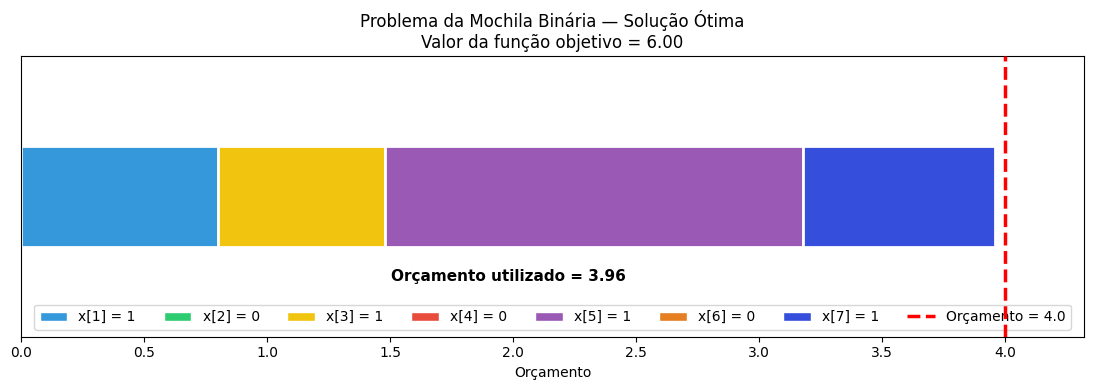

In [22]:
# ============================================================
# 4. EXECUÇÃO
# ============================================================

massa = ler_massa(codigo_cmpl)

resultados = ler_resultados_modelo(modelo)

plotar_mochila(massa, resultados)

# Source code

The source code is available on Github:
Cmpl official realeases: https://github.com/coin-or/Cmpl

Cmpl working git: https://github.com/MikeSteglich/Cmpl2

Coliop: https://github.com/MikeSteglich/Coliop

pyCmpl: https://github.com/MikeSteglich/pyCmpl3